In [5]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [7]:
import pandas as pd
df= pd.read_csv("/content/drive/MyDrive/datasets/online_retail.csv", encoding= "ISO-8859-1")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Clean the dataset

In [11]:
# convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
# remove rows without customer ids
df = df.dropna(subset=["CustomerID"])
# remove negative quantities
df = df[df["Quantity"] > 0]
# remove zero or negative prices
df = df[df["UnitPrice"] > 0]
# create revenue column
df["Revenue"] =  df["Quantity"]*df["UnitPrice"]

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# Revenue by Country

In [13]:
revenue_country =(df.groupby("Country")["Revenue"].sum().sort_values(ascending=False))
revenue_country.head(10)

,Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


<Axes: title={'center': 'Top 10 countries by Revenue'}, xlabel='Country'>

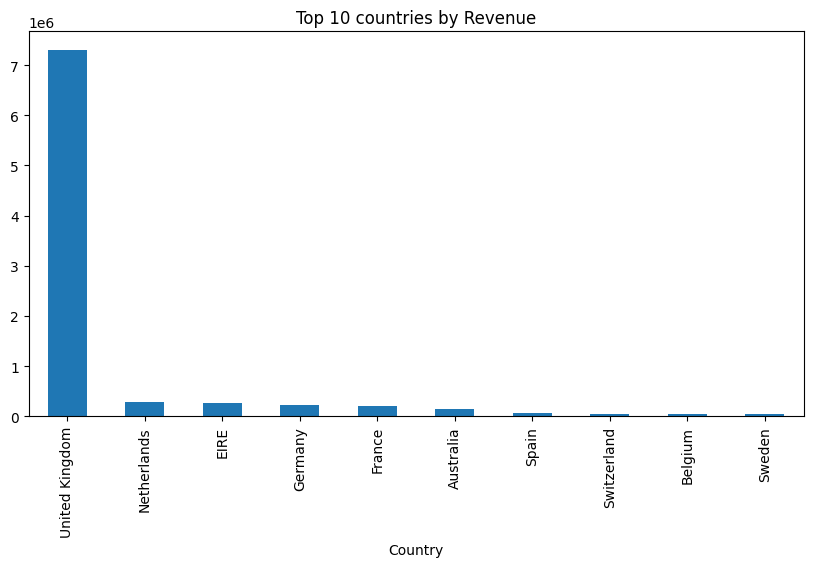

In [15]:
revenue_country.head(10).plot(kind = "bar", figsize=(10,5), title= "Top 10 countries by Revenue")

# Top customers by revenue

In [16]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
top_customers.head(10)

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


<Axes: title={'center': 'Top 10 customers by Revenue'}, xlabel='CustomerID'>

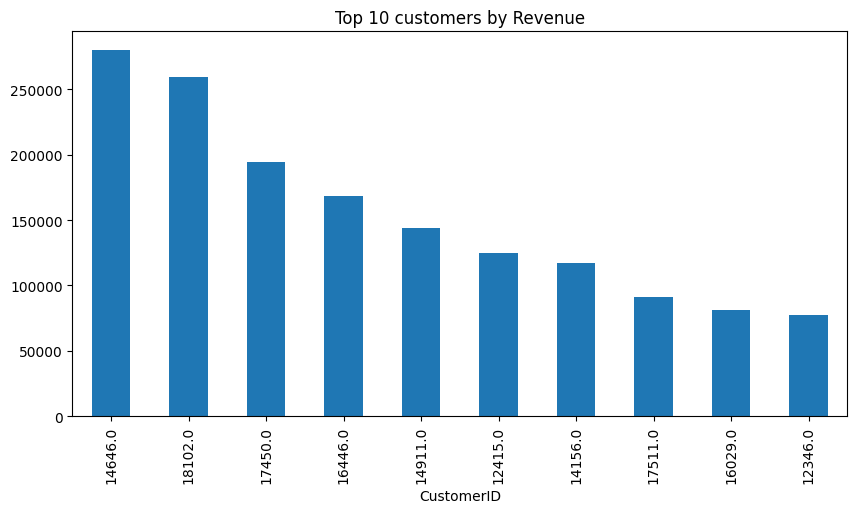

In [17]:
top_customers.head(10).plot(kind = "bar",
                            figsize=(10,5),
                            title= "Top 10 customers by Revenue"
                            )

# Monthly Revenue Trend

In [18]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue= (
    df.groupby("Month")["Revenue"].sum()
)
monthly_revenue.head(10)

,Revenue
Month,
2010-12,572713.890
2011-01,569445.040
2011-02,447137.350
2011-03,595500.760
2011-04,469200.361
2011-05,678594.560
2011-06,661213.690
2011-07,600091.011
2011-08,645343.900


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month'>

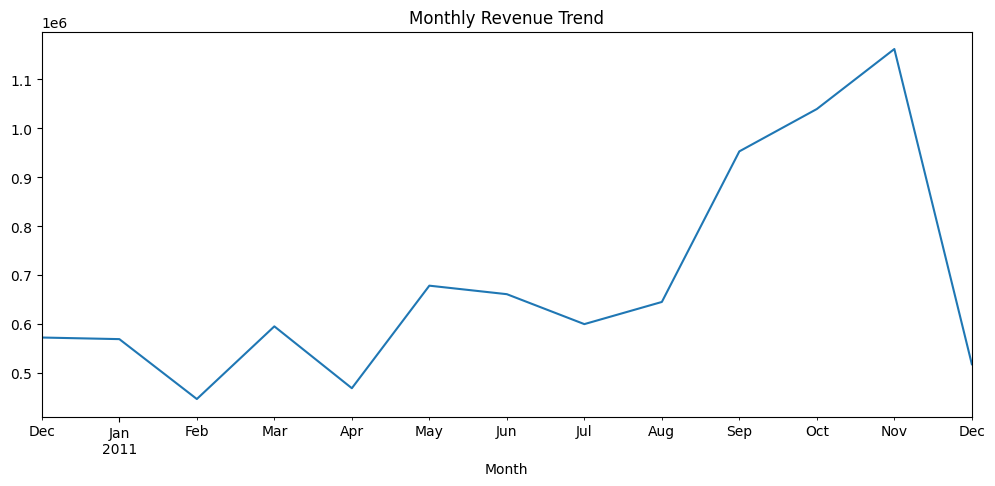

In [19]:
monthly_revenue.plot(
    figsize=(12,5),
    title= "Monthly Revenue Trend"
)